# Data Analysis

This notebook shows a simple statistical summary, a heatmap, histograms, boxplots, and feature importance.

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
import os


In [19]:
df = pd.read_csv('data/cleaned_data.csv')
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,0.529878,0.695610,0.314146,0.354827,0.273973,0.149268,0.264878,0.596291,0.336585,0.172825,0.692683,0.188537,0.774634,0.513171
std,0.189006,0.460373,0.343214,0.165252,0.117791,0.356527,0.263939,0.175616,0.472772,0.189503,0.308878,0.257699,0.206887,0.500070
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.395833,0.000000,0.000000,0.245283,0.194064,0.000000,0.000000,0.465649,0.000000,0.000000,0.500000,0.000000,0.666667,0.000000
50%,0.562500,1.000000,0.333333,0.339623,0.260274,0.000000,0.500000,0.618321,0.000000,0.129032,0.500000,0.000000,0.666667,1.000000
75%,0.666667,1.000000,0.666667,0.433962,0.340183,0.000000,0.500000,0.725191,1.000000,0.290323,1.000000,0.250000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


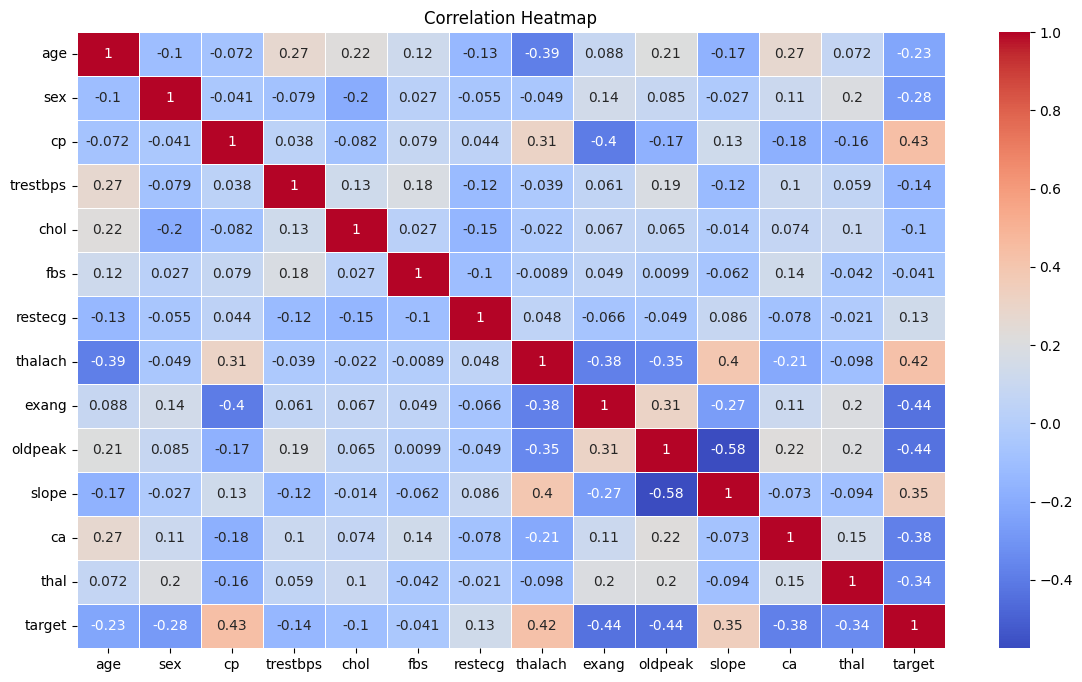

In [20]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

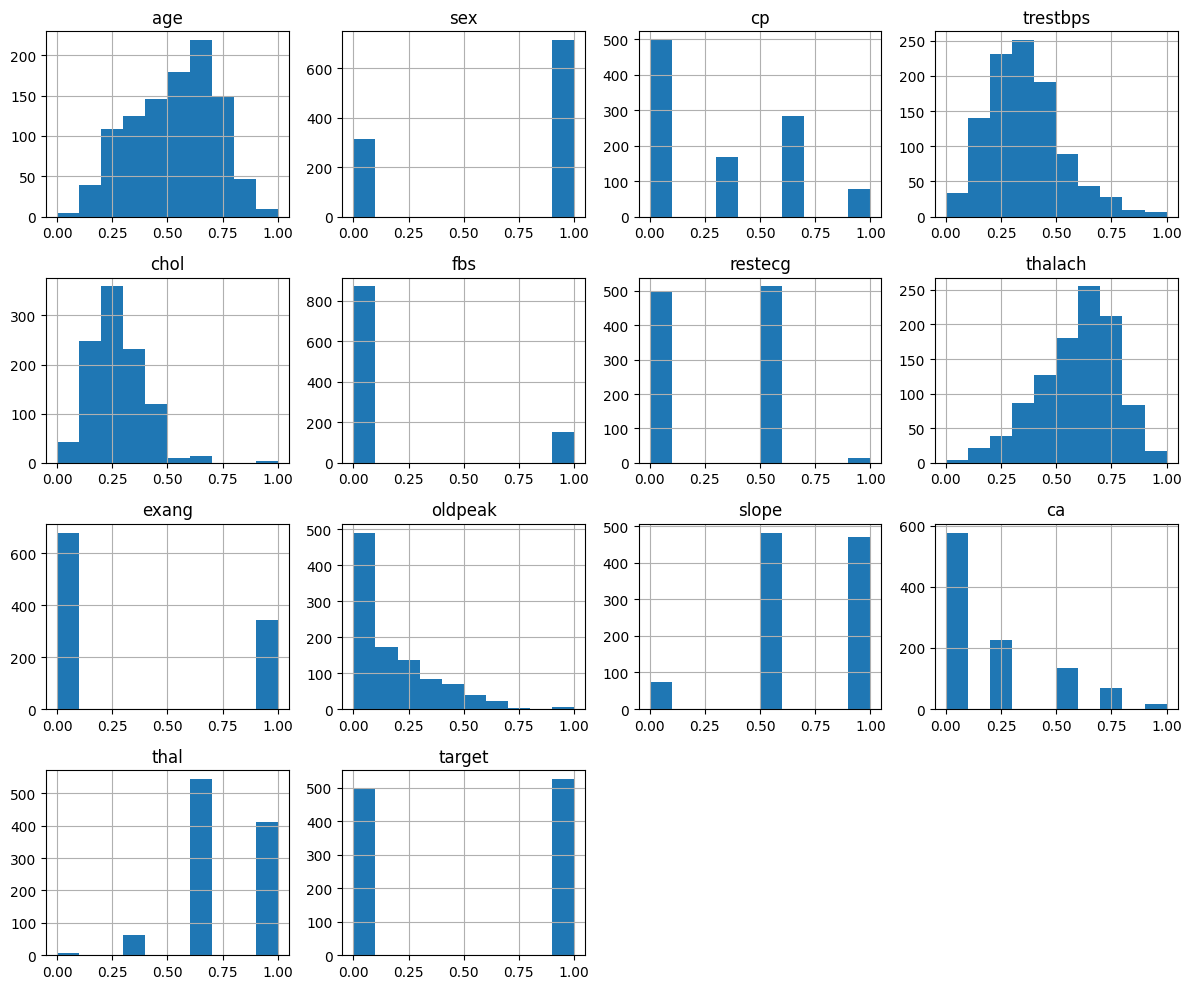

In [21]:
df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()

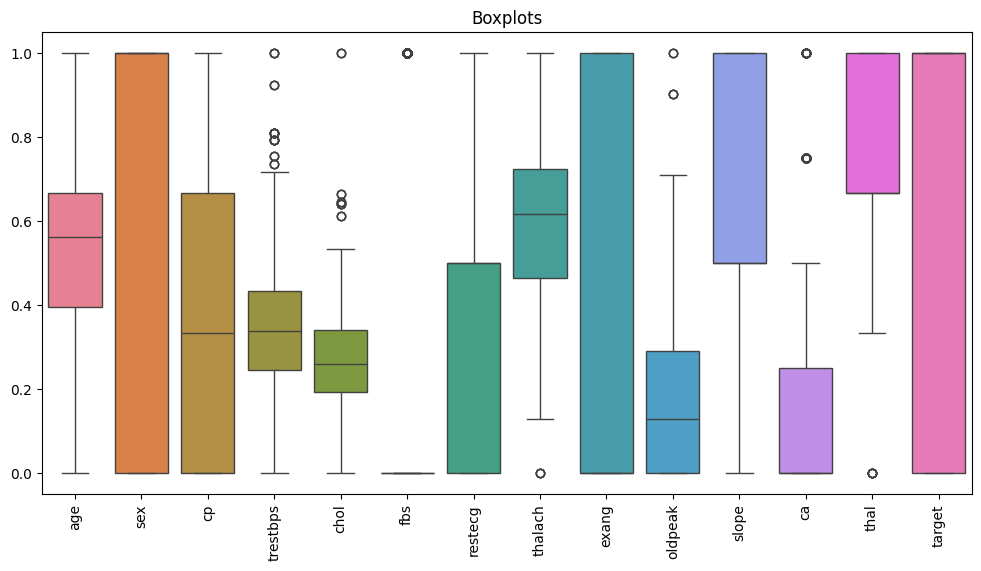

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title('Boxplots')
plt.show()

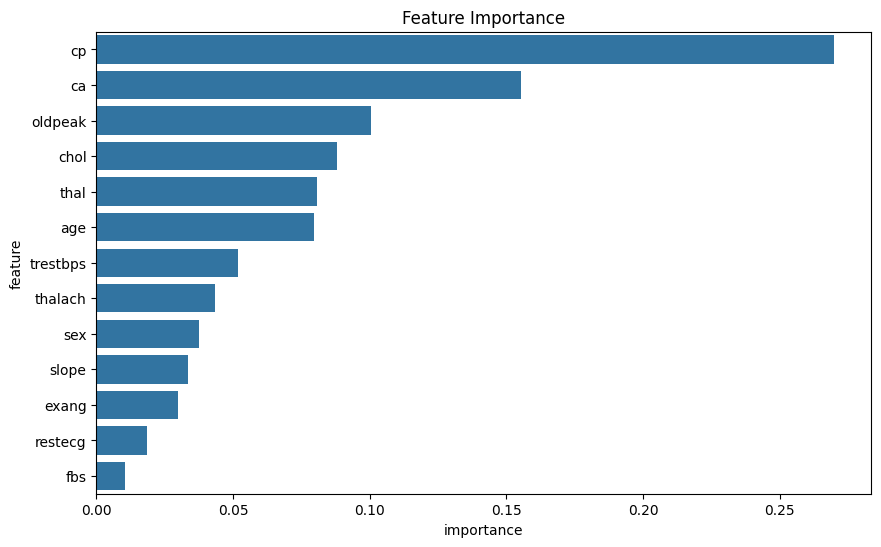

,feature,importance
2,cp,0.270006
11,ca,0.155398
9,oldpeak,0.100665
4,chol,0.088038
12,thal,0.080872
0,age,0.079670
3,trestbps,0.051714
7,thalach,0.043401
1,sex,0.037490
10,slope,0.033580


In [23]:
X = df.drop('target', axis=1)
y = df['target']

model = DecisionTreeClassifier(random_state=42)
model.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature')
plt.title('Feature Importance')
plt.show()

importance_df